In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../../")

#spectrome modules
from spectrome.utils import functions, path
from spectrome.brain import Brain


from spectrome.forward import ntf_local_stimulus as nt_stim
from spectrome.forward import ntf_local as nt_nostim
from spectrome.forward import ntf_local_stimulus as nt_stim

from scipy.io import loadmat
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import fdrcorrection

from scipy.io import savemat
import pickle as pkl

In [2]:
# All regions
df=pd.read_excel('../../ListROIs_DK.xlsx')
all_regions=[]
all_regions_idx=[]
for i,r in df.iterrows():
    all_regions_idx.append(i)
    all_regions.append(r['ROI'].strip("'"))

all_regions=[r.replace(' L', '-lh').replace(' R', '-rh') for r in all_regions[:68]]

In [45]:
# 'superiorparietal L', r = 0.567,  p_FDR = 0.00023763
# 'pericalcarine L', r = -0.525,  p_FDR = 0.00077489
# 'cuneus R', r = -0.488,  p_FDR = 0.00180515
# 'superiorparietal R', r = 0.487,  p_FDR = 0.00180515
# 'parahippocampal R', r = 0.463,  p_FDR = 0.00341764
# 'pericalcarine R', r = -0.449,  p_FDR = 0.00467706
# 'cuneus L', r = -0.416,  p_FDR = 0.01000718
# 'fusiform R', r = 0.420,  p_FDR = 0.01000718
# 'transversetemporal L', r = -0.355,  p_FDR = 0.04687848

# all_r_values = [ 0.12310737, -0.06664214,  0.08301076, -0.12340363, -0.00682601,
#        -0.01580138, -0.41559982, -0.48799502,  0.29534231, -0.05918839,
#        -0.00858947, -0.09614734,  0.03659876,  0.41979844, -0.03259466,
#         0.3431257 ,  0.03338622, -0.02384095, -0.08888   , -0.02591268,
#        -0.02143598, -0.18361238, -0.20518789, -0.23024964, -0.30330764,
#         0.01124919, -0.01837305, -0.27962831, -0.09602093, -0.23166108,
#         0.19575089,  0.00350045, -0.06413833, -0.0848806 ,  0.16036688,
#         0.46313901, -0.12898126,  0.01513273, -0.15649046, -0.02279106,
#        -0.09270443,  0.17271868, -0.52549363, -0.44860926, -0.0259262 ,
#         0.3179166 ,  0.1034315 , -0.25722975,  0.0140781 , -0.05442698,
#        -0.17067784, -0.27105175, -0.02831828, -0.12340502, -0.18894972,
#         0.04949377,  0.03621503, -0.04474695,  0.56690094,  0.48692761,
#         0.24535845, -0.02438979,  0.31257727,  0.34568927, -0.1540353 ,
#         0.01070726, -0.35528421,  0.2691841 ]

all_r_values = [ 0.18378152, -0.09684795,  0.07139455, -0.09324036, -0.09675131,
        0.04178892, -0.35729973, -0.50543713,  0.19833179, -0.24771617,
        0.01330401, -0.12259494, -0.08146905,  0.35850574,  0.01568806,
        0.24947454, -0.02094162, -0.07364513, -0.15942198, -0.05389847,
       -0.05971691, -0.17471788, -0.18196281, -0.23225917, -0.2841138 ,
       -0.01753842, -0.02795914, -0.2957975 , -0.15671219, -0.18480304,
        0.17512985, -0.0946226 , -0.08679169,  0.01792028,  0.00544385,
        0.32984317, -0.14632009,  0.00763954, -0.07097376,  0.01462325,
       -0.04125052,  0.01927572, -0.45205995, -0.39747824, -0.05802991,
        0.20750168,  0.14813964, -0.25385297,  0.13810692, -0.01168416,
       -0.17832841, -0.32496979,  0.03169736,  0.01739983, -0.15595043,
       -0.0385448 ,  0.04325555, -0.12535835,  0.57659019,  0.41737562,
        0.28431533, -0.04468784,  0.33149681,  0.31912734, -0.08176387,
        0.09822728, -0.32248495,  0.2938409 ]

# significant_regions_list = [58, 42, 7, 59, 35, 43, 6, 13, 66]
# significant_r_values = [0.567, -0.525, -0.488, 0.487, 0.463, -0.449, -0.416, 0.420, -0.355]
# regions = [all_regions[i] for i in significant_regions_list]
df_taue = pd.DataFrame(all_r_values, index=all_regions, columns=['r'])

In [46]:
df_taue

,r
bankssts-lh,0.183782
bankssts-rh,-0.096848
caudalanteriorcingulate-lh,0.071395
caudalanteriorcingulate-rh,-0.093240
caudalmiddlefrontal-lh,-0.096751
...,...
supramarginal-rh,0.319127
temporalpole-lh,-0.081764
temporalpole-rh,0.098227
transversetemporal-lh,-0.322485


In [47]:
significant_regions_list = [58, 42, 7, 59, 35, 43, 6, 13, 66]
significant_regions_list2 = [58, 7, 42, 59, 43]
significant_regions = [all_regions[i] for i in significant_regions_list2]

In [48]:
significant_regions

['superiorparietal-lh',
 'cuneus-rh',
 'pericalcarine-lh',
 'superiorparietal-rh',
 'pericalcarine-rh']

### Brain Plots

In [49]:
'''
Code: To plot various brain region from DK atlas
'''
import xarray as xr
import mne
import matplotlib.pyplot as plt
from mne.viz import plot_brain_colorbar
from mne.viz import Brain
from mne.datasets import fetch_fsaverage
import os.path as op
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
from matplotlib import colormaps as cmaps
import numpy as np

# pip install netCDF4 h5netcdf
# !pip install pyvistaqt ipywidgets

In [50]:
data_xr = xr.open_dataarray("individual_psd_reordered_matlab.nc")
psd = data_xr.values
regions = data_xr["regionx"].values

In [51]:
regions_mne = []
count = 0

for i in range(len(regions)):
    if regions[i][0:2] == 'LH':
        regionname = regions[i][2:]
        regions_mne.append(regionname + '-lh')

    if regions[i][0:2] == 'RH':
        regionname = regions[i][2:]
        regions_mne.append(regionname + '-rh')


In [52]:
# Fetch fsaverage dataset
fs_dir = fetch_fsaverage(verbose=True)
subjects_dir = op.dirname(fs_dir)

# Load fsaverage subject details
subject = "fsaverage"
trans = "fsaverage"  # Built-in fsaverage transformation in MNE
src_fname = op.join(fs_dir, "bem", "fsaverage-ico-5-src.fif")

# Read source spaces
src = mne.read_source_spaces(src_fname)

# Load labels from the fsaverage atlas
labels = mne.read_labels_from_annot(subject, parc="aparc", subjects_dir=subjects_dir)

0 files missing from root.txt in /Users/apurbadebnath/mne_data/MNE-fsaverage-data
0 files missing from bem.txt in /Users/apurbadebnath/mne_data/MNE-fsaverage-data/fsaverage
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
Reading labels from parcellation...
   read 35 labels from /Users/apurbadebnath/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/apurbadebnath/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.annot


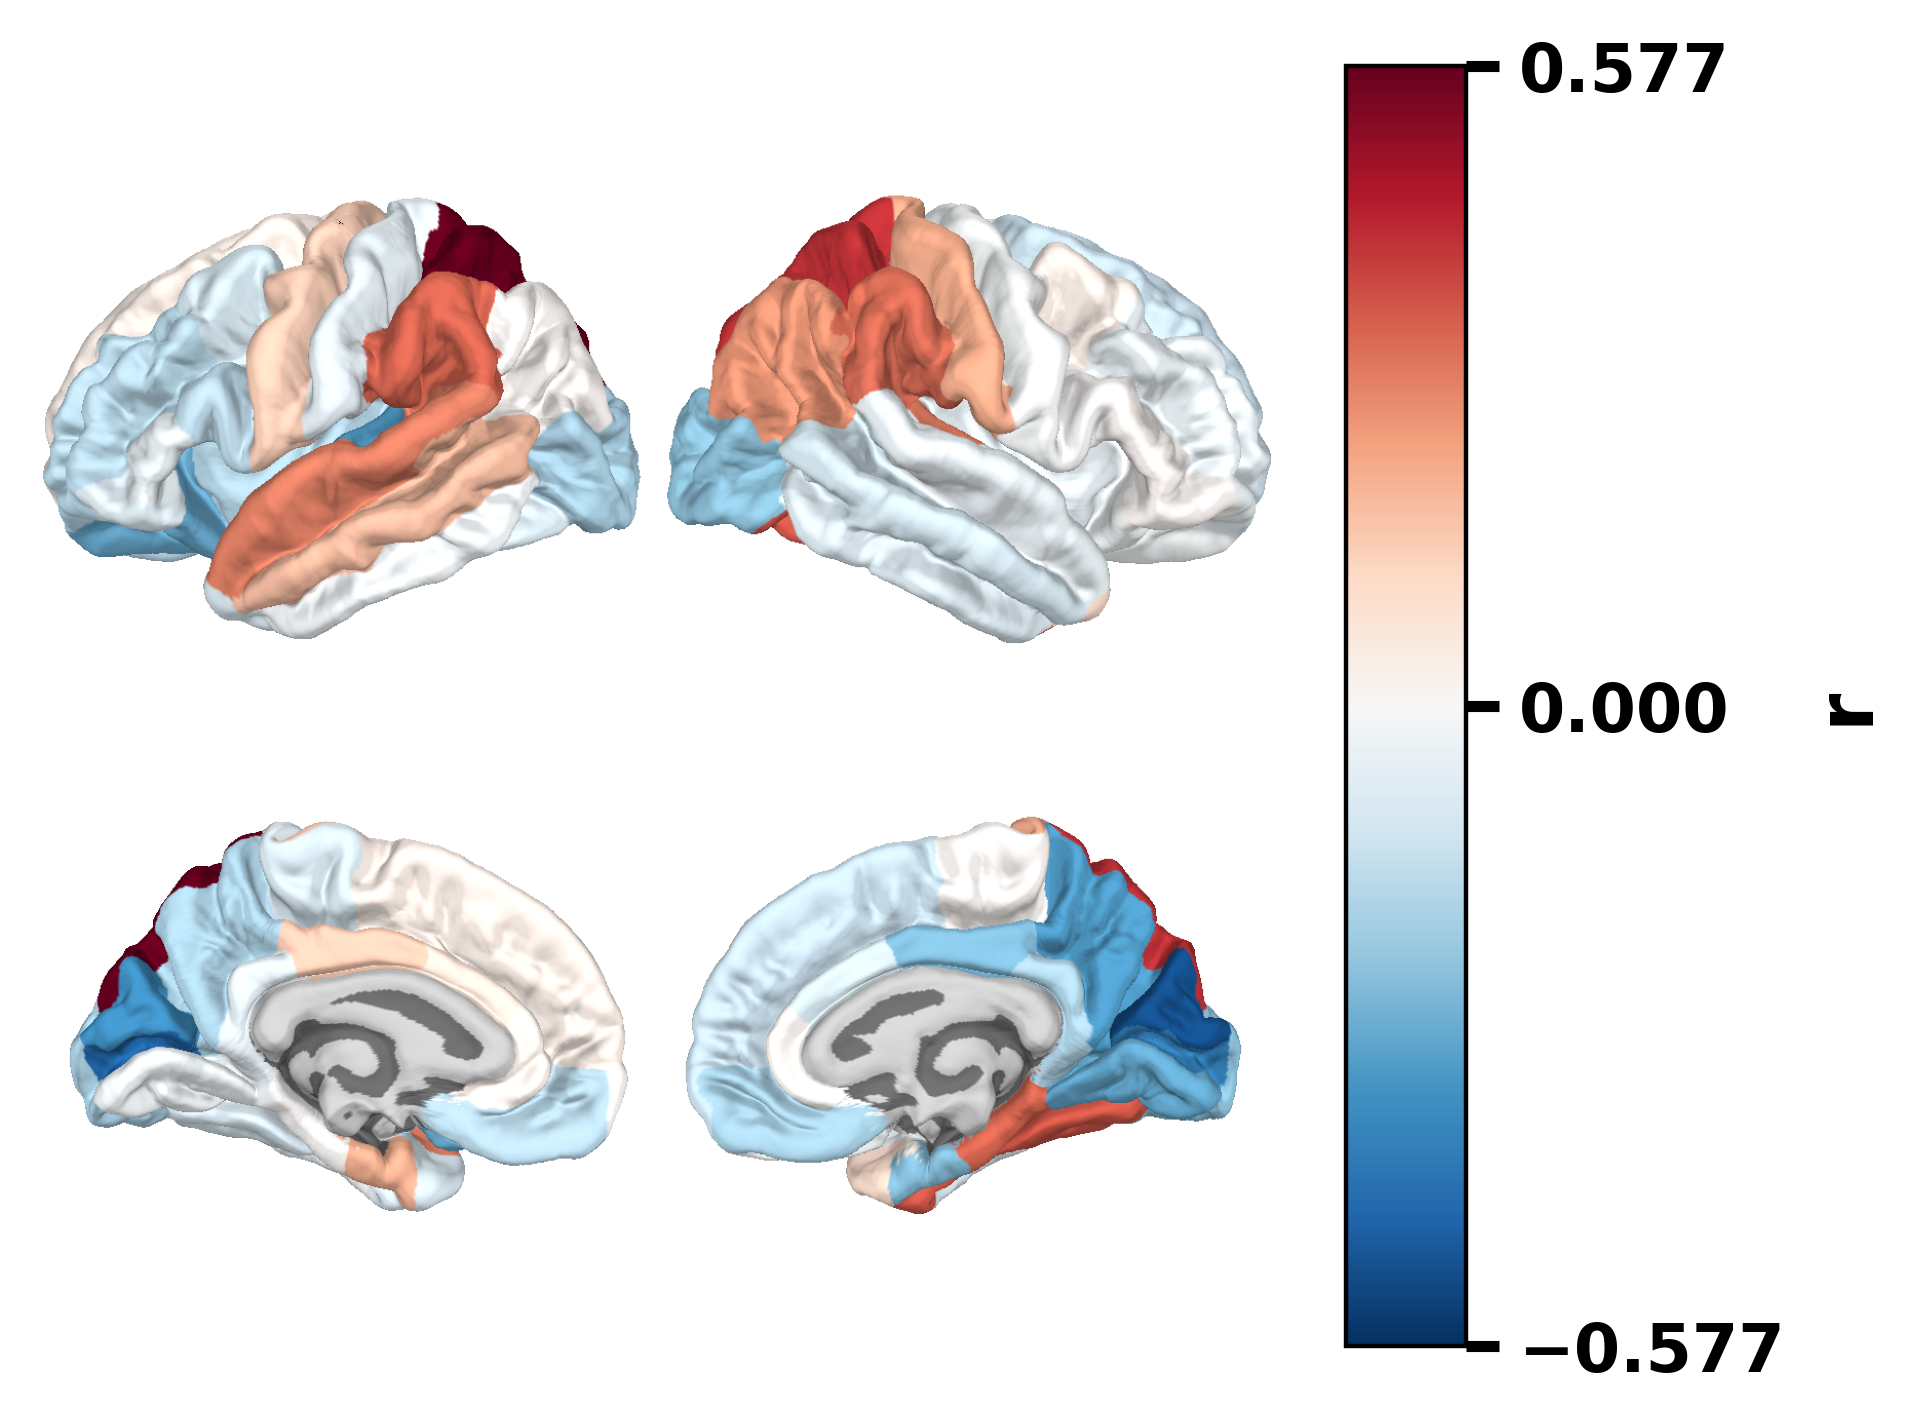

In [55]:
max_val = df_taue["r"].max()
min_val = df_taue["r"].min()

# max_val = df_taue[['S3']].to_numpy().max()
# min_val = df_taue[['S3']].to_numpy().min()

##For plotting mean(MI/RS-1)
roi_tvalues = dict(zip(list(df_taue.index), list(df_taue['r'])))

brain = Brain(
    subject=subject,
    subjects_dir=subjects_dir,
    surf="pial",
    hemi="split",  
    background="white",
    views=["lat", "med"],
    # views=["dorsal"],
    size=(600, 600),
    # offset='auto',
    # view_layout='horizontal',
    # show=False, 
)

cmap = cmaps.get_cmap("RdBu_r") #changing RdBu_r to RdBu to make reddish appearance for greater values
# vmin, vmax = -np.max(list(df_taue['S3'])), np.max(list(df_taue['S3']))  
vmin, vmax = -max_val, max_val # Use the max value from all sessions
norm = Normalize(vmin=vmin, vmax=vmax)


for label in labels:
    if label.name in all_regions:  
        t_value = roi_tvalues[label.name]
        rgba_color = cmap(norm(t_value))
        brain.add_label(label, color=rgba_color[:4]) 



clim = dict(kind="value", lims=[vmin, (vmin+vmax)/2, vmax])
brain.save_image("pfdr_taue_meg_sess1.png")
#the combined plot
fig, ax = plt.subplots(figsize=(6, 4), dpi=400) 

brain_image = plt.imread("pfdr_taue_meg_sess1.png")
ax.imshow(brain_image)
ax.axis('off')  

#vertical colorbar next to the brain image
cbar_ax = fig.add_axes([0.8, 0.1, 0.05, 0.8]) 
# [0.15, 0.1, 0.7, 0.3]-->becomes horizontal
# [0.8, 0.1, 0.05, 0.8]--vertical
cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cbar_ax)

# Set colorbar label with larger font
cb.set_label("r", fontsize=14, weight='bold')

# Set custom ticks and formatting
cb.set_ticks([vmin, (vmin + vmax) / 2, vmax])
cb.ax.tick_params(
    axis='y',
    which='both',
    length=6,       
    width=2,       
    colors='black', 
    # direction='out',
    labelsize=12    
)

# bolden each tick label
for label in cb.ax.get_yticklabels():
    label.set_fontweight('bold')


plt.savefig(f"/Users/apurbadebnath/Desktop/brain_plot_repeated_measure_r.png", dpi=400)
plt.show()


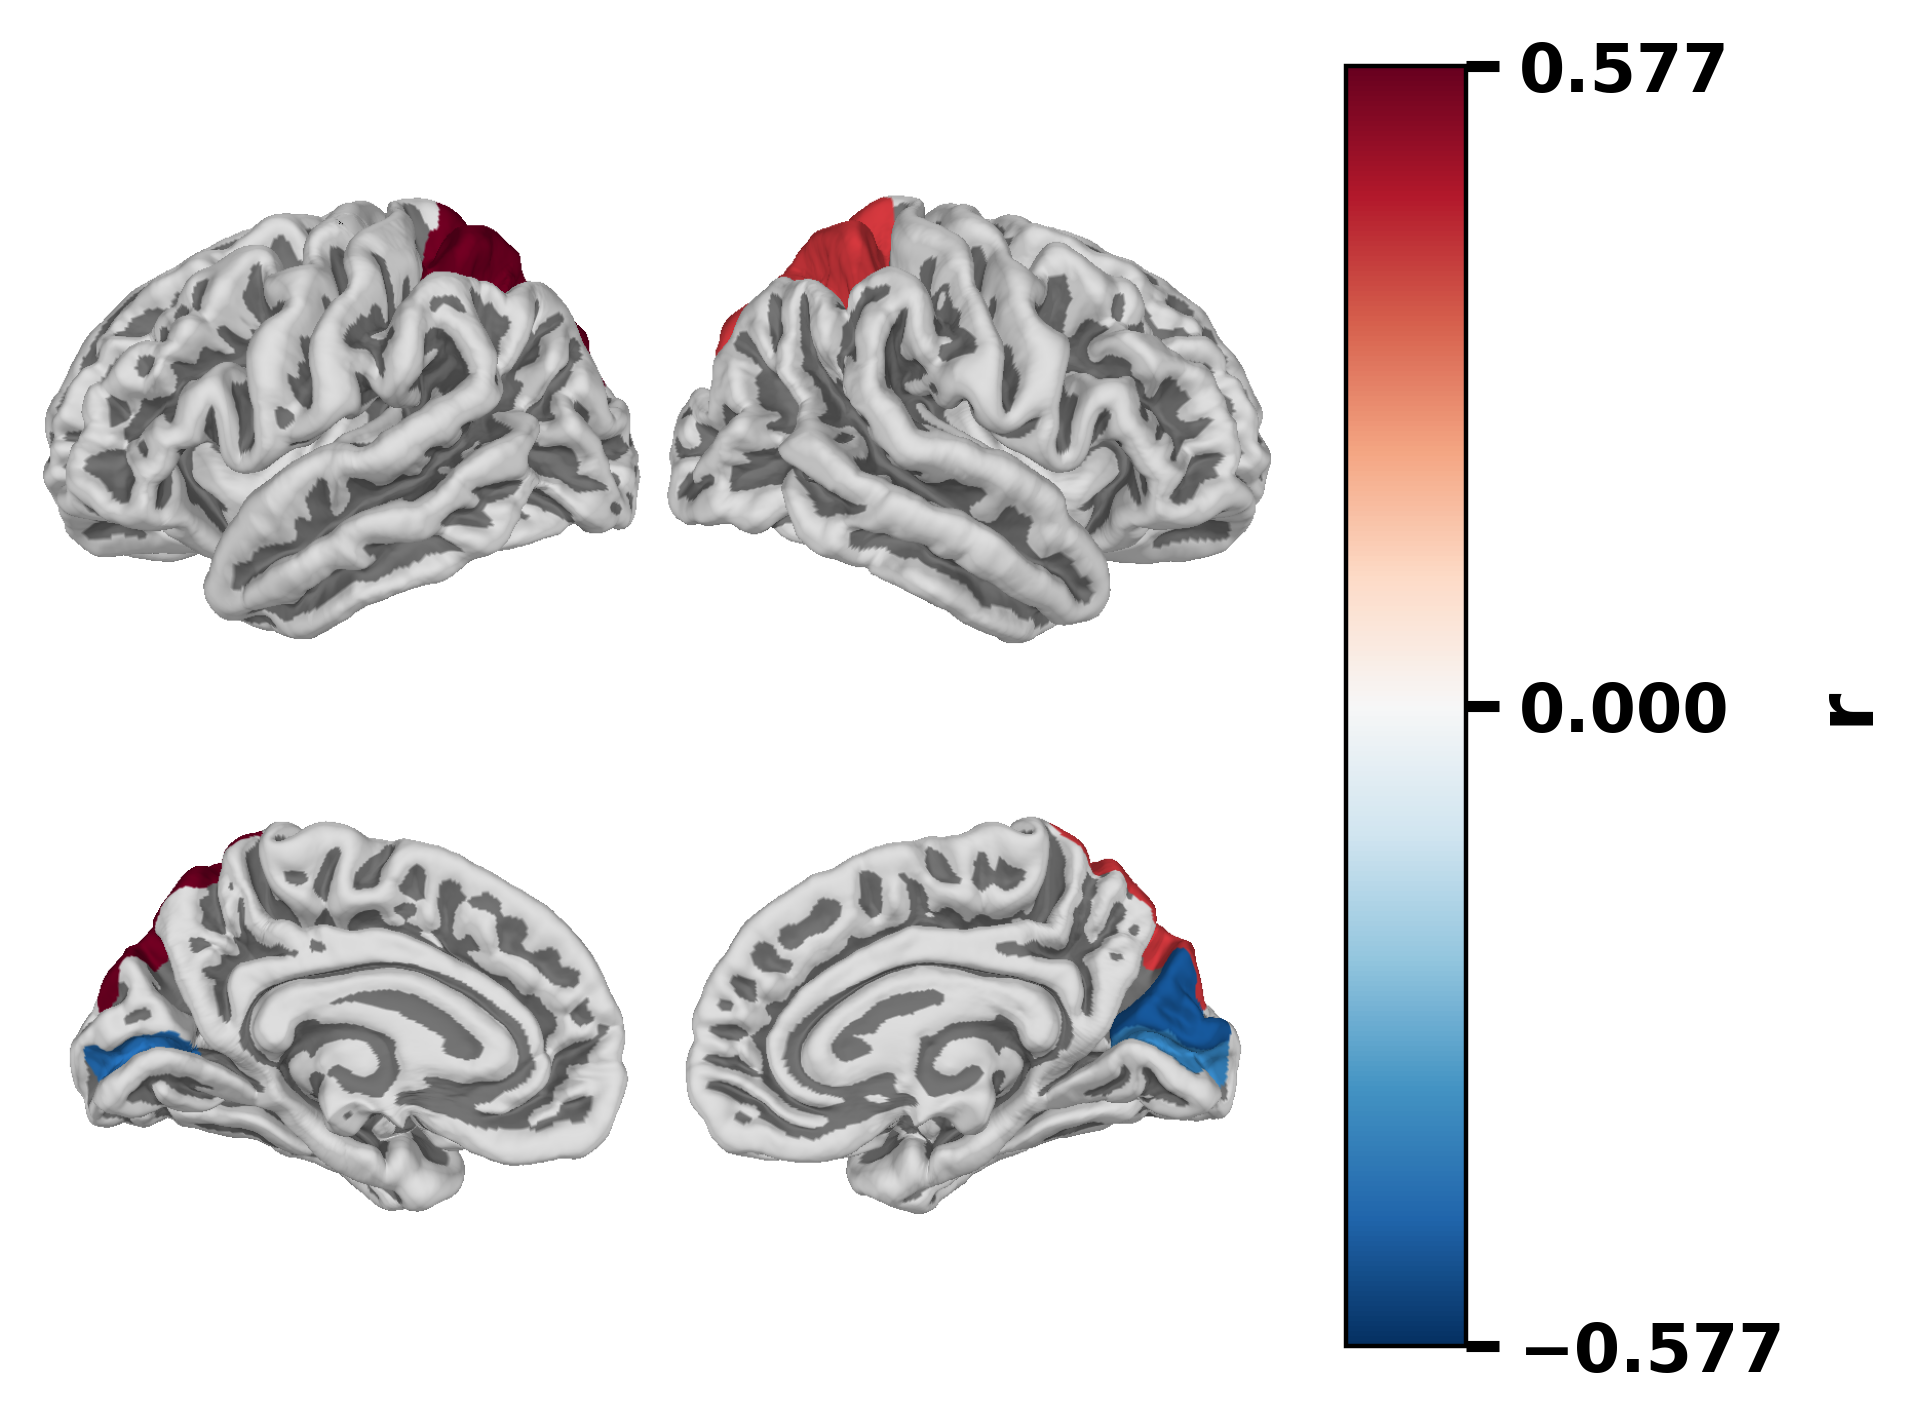

In [54]:
max_val = df_taue["r"].max()
min_val = df_taue["r"].min()

# max_val = df_taue[['S3']].to_numpy().max()
# min_val = df_taue[['S3']].to_numpy().min()

##For plotting mean(MI/RS-1)
roi_tvalues = dict(zip(list(df_taue.index), list(df_taue['r'])))

brain = Brain(
    subject=subject,
    subjects_dir=subjects_dir,
    surf="pial",
    hemi="split",  
    background="white",
    views=["lat", "med"],
    # views=["dorsal"],
    size=(600, 600),
    # offset='auto',
    # view_layout='horizontal',
    # show=False, 
)

cmap = cmaps.get_cmap("RdBu_r") #changing RdBu_r to RdBu to make reddish appearance for greater values
# vmin, vmax = -np.max(list(df_taue['S3'])), np.max(list(df_taue['S3']))  
vmin, vmax = -max_val, max_val # Use the max value from all sessions
norm = Normalize(vmin=vmin, vmax=vmax)


for label in labels:
    if label.name in significant_regions:  
        t_value = roi_tvalues[label.name]
        rgba_color = cmap(norm(t_value))
        brain.add_label(label, color=rgba_color[:4]) 



clim = dict(kind="value", lims=[vmin, (vmin+vmax)/2, vmax])
brain.save_image("pfdr_taue_meg_sess1.png")
#the combined plot
fig, ax = plt.subplots(figsize=(6, 4), dpi=400) 

brain_image = plt.imread("pfdr_taue_meg_sess1.png")
ax.imshow(brain_image)
ax.axis('off')  

#vertical colorbar next to the brain image
cbar_ax = fig.add_axes([0.8, 0.1, 0.05, 0.8]) 
# [0.15, 0.1, 0.7, 0.3]-->becomes horizontal
# [0.8, 0.1, 0.05, 0.8]--vertical
cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cbar_ax)

# Set colorbar label with larger font
cb.set_label("r", fontsize=14, weight='bold')

# Set custom ticks and formatting
cb.set_ticks([vmin, (vmin + vmax) / 2, vmax])
cb.ax.tick_params(
    axis='y',
    which='both',
    length=6,       
    width=2,       
    colors='black', 
    # direction='out',
    labelsize=12    
)

# bolden each tick label
for label in cb.ax.get_yticklabels():
    label.set_fontweight('bold')


# plt.savefig(f"/Users/apurbadebnath/Desktop/brain_plot_significant_taue_mi_rs_sess1.png", dpi=400)
plt.show()
